Index(['CHL_RFU', 'Reagents_moleccm3', 'SA_moleccm3', 'IA_moleccm3',
       'Monomers_moleccm3', 'NitrogenMonomers_moleccm3', 'Dimers_moleccm3',
       'NitrogenDimers_moleccm3', 'TotalOrganics_moleccm3', 'PE_rfu',
       'FCO2Li_umolm2s', 'PAR_umolm2s', 'dms_ppt', 'isp_ppt', 'mts_ppt',
       'OD_mgl', 'ODsaturation_perc', 'PAR2_wm2', 'TDS_mgl',
       'concentrationrange_dperc', 'iceconcentration_x',
       'seaiceclassification_x', 'CO_ppb', 'NO_ppb', 'NO2_ppb', 'O3_ppb',
       'SO2_ppb', 'turbidity_fnu', 'pH_x', 'salinity_psu', 'temperature_c',
       'albedo', 'neg0p8t2_ptcm3', 'neg2t2p3_ptcm3', 'ionRatio_x',
       'WindSpeedU_ms', 'WindSpeedU10_ms', 'WindDirectionWD_dd',
       'WindUcomponent', 'WindVcomponent', 'season'],
      dtype='str')
datetime64[s]
['CHL_RFU', 'PE_rfu', 'temperature_c', 'WindUcomponent', 'WindVcomponent', 'dms_ppt', 'FCO2Li_umolm2s']
                     CHL_RFU  PE_rfu  temperature_c  WindUcomponent  \
Time                                              

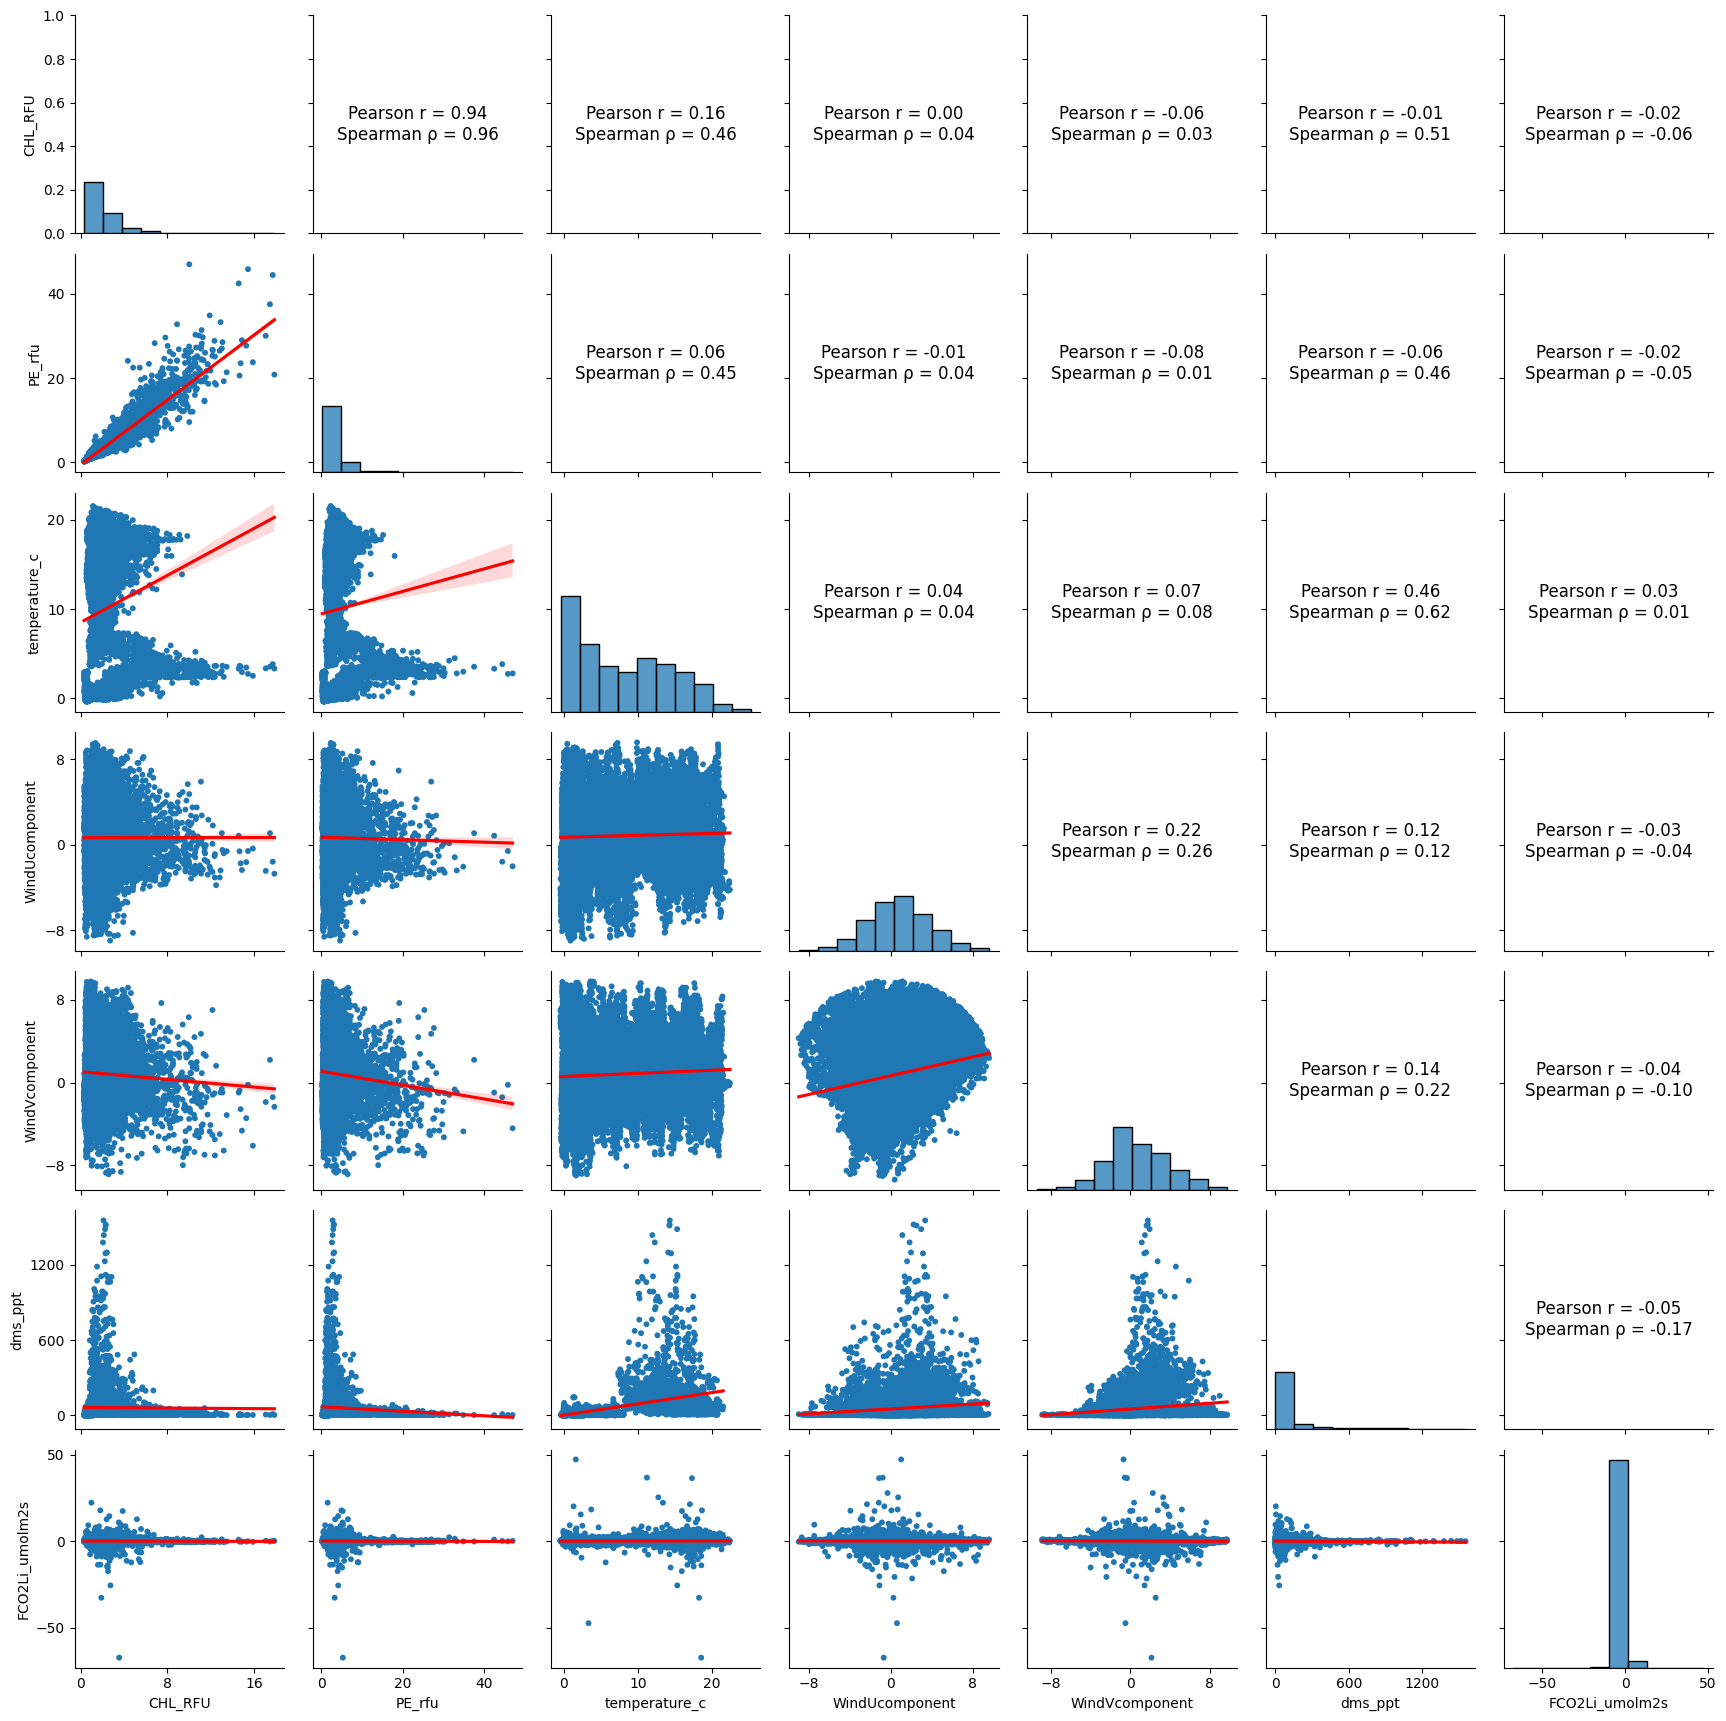

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as mticker


NON_NUMERIC = ["season"]

COMBINED_PATH = "../local/Tvarminne/combined/combined.csv"

df = pd.read_csv(COMBINED_PATH, engine='pyarrow', index_col="Time")

GROUP_MAP_KEY_ORIGINAL = "original"
GROUP_MAP_KEY_NEW = "new"

GROUP_MAP = {
    "Dominik" : ["CO_ppb", "NO_ppb", "SO2_ppb","SA_moleccm3","Dimers_moleccm3"],
    "Areeb" : ["salinity_psu", "TDS_mgl", "Reagents_moleccm3", "FCO2Li_umolm2s", "temperature_c"],
    "marineaurora1": ["CHL_RFU", "PE_rfu", "OD_mgl", "temperature_c", "PAR2_wm2"],
    "marineaurora2": ["CHL_RFU", "PE_rfu", "temperature_c", "WindUcomponent", "WindVcomponent", "dms_ppt", "FCO2Li_umolm2s"],
    "meteojeni1": ["WindUcomponent", "WindVcomponent", "turbidity_fnu", "CHL_RFU", "PE_rfu"],
    "meteojeni2": ["WindUcomponent", "WindVcomponent", "dms_ppt", ],

}

print(df.columns)

print(df.index.dtype)

df_subset_columns = GROUP_MAP.get("marineaurora2", [])

print(df_subset_columns)

df_subset = df[df_subset_columns]

def corrfunc(x, y, **kws):
    r_pearson = float(x.corr(y, method="pearson"))
    r_spearman = float(x.corr(y, method="spearman"))

    ax = plt.gca()
    ax.annotate(f"Pearson r = {r_pearson:.2f}\nSpearman ρ = {r_spearman:.2f}",
                xy=(.5, .5),
                xycoords=ax.transAxes,
                ha='center',
                va='center',
                fontsize=12)

def scatter_reg(x, y, **kwargs):
    ax = plt.gca()
    
    # Scatter plot
    sns.scatterplot(
        x=x, y=y, ax=ax,
        alpha=1,
        size=1,
        edgecolor="none",
        **kwargs
    )
    
    # Regression line
    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        scatter=False,
        line_kws={"color": "red"}
    )
    
    # Log scale (apply only if values are positive)
    # ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(nbins=3)
    )

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(nbins=3)
    )

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

    # ax.xaxis.set_major_locator(
    #     mticker.LogLocator(numticks=5)
    # )
    # ax.yaxis.set_major_locator(
    #     mticker.LogLocator(numticks=5)
    # )

print(df_subset.head())
g = sns.PairGrid(df_subset)
g.map_upper(corrfunc)          # correlation in upper triangle
g.map_lower(scatter_reg)
# g.map_lower(sns.scatterplot)   # scatterplots
g.map_diag(sns.histplot, bins=10)       # distributions

plt.show()



# g = sns.pairplot(df_subset, diag_kind="hist")

# for ax in g.axes.flatten():
#     if ax is not None:
#         ax.autoscale()

# plt.show()

# plt.show()

